# 📦 E-Commerce Sales Analysis
**Dataset:** Indian E-Commerce Orders (Kaggle)  
**Herramientas:** Python · Pandas · DuckDB · Seaborn · Matplotlib  
**Autor:** Eddy Contreras

---

## Objetivo
Analizar el comportamiento de ventas, rentabilidad por producto y categoría, y perfil de los clientes principales de un e-commerce indio durante 2018–2019.

---

## Estructura del Proyecto
1. [Importaciones](#1-importaciones)
2. [Carga de Datos](#2-carga-de-datos)
3. [EDA — Orders List](#3-eda--orders-list)
4. [EDA — Order Details](#4-eda--order-details)
5. [Limpieza y Transformación](#5-limpieza-y-transformación)
6. [Análisis de Ventas](#6-análisis-de-ventas)
7. [Análisis de Productos](#7-análisis-de-productos)
8. [Análisis de Clientes](#8-análisis-de-clientes)
9. [Análisis Geográfico](#9-análisis-geográfico)
10. [Conclusiones](#10-conclusiones)


## 1. Importaciones

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb as dk
from sqlalchemy import create_engine
from IPython.display import display

## 2. Carga de Datos

In [2]:
df_orders_list    = pd.read_csv('List of Orders.csv')
df_orders_details = pd.read_csv('Order Details.csv')

## 3. EDA — Orders List

In [3]:
df_orders_list.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [4]:
df_orders_list.shape

(560, 5)

In [5]:
df_orders_list.isnull().sum()

Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64

In [6]:
df_orders_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      500 non-null    str  
 1   Order Date    500 non-null    str  
 2   CustomerName  500 non-null    str  
 3   State         500 non-null    str  
 4   City          500 non-null    str  
dtypes: str(5)
memory usage: 22.0 KB


In [7]:
total      = df_orders_list['Order ID'].shape[0]
unicos     = df_orders_list['Order ID'].nunique()
duplicados = total - unicos

print(f'Total registros  : {total}')
print(f'IDs únicos       : {unicos}')
print(f'Duplicados       : {duplicados}')

Total registros  : 560
IDs únicos       : 500
Duplicados       : 60


## 4. EDA — Order Details

In [8]:
df_orders_details.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,66.0,-12.0,5,Clothing,Stole
2,B-25601,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,168.0,-111.0,2,Electronics,Phones


In [9]:
df_orders_details.shape

(1500, 6)

In [10]:
df_orders_details.isnull().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64

In [11]:
df_orders_details.nunique()

Order ID        500
Amount          585
Profit          401
Quantity         14
Category          3
Sub-Category     17
dtype: int64

In [12]:
# Estadísticas descriptivas
# HALLAZGO: el Q1 de profit es negativo — hay ventas con pérdida desde el inicio
df_orders_details.describe()

,Amount,Profit,Quantity
count,1500.000000,1500.000000,1500.000000
mean,287.668000,15.970000,3.743333
std,461.050488,169.140565,2.184942
min,4.000000,-1981.000000,1.000000
25%,45.000000,-9.250000,2.000000
50%,118.000000,9.000000,3.000000
75%,322.000000,38.000000,5.000000
max,5729.000000,1698.000000,14.000000


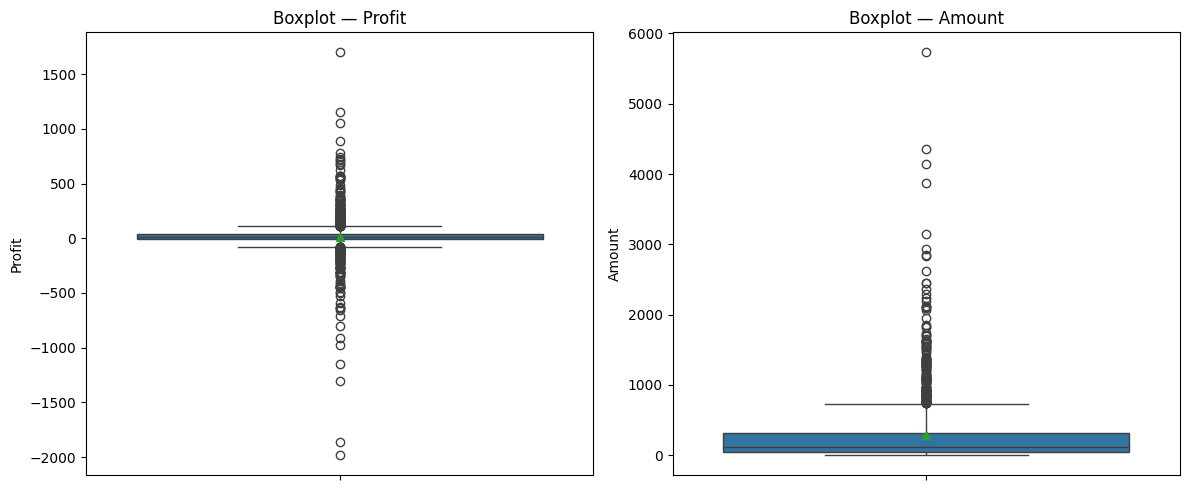

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(df_orders_details['Profit'], ax=ax[0], showmeans=True)
ax[0].set_title('Boxplot — Profit')
sns.boxplot(df_orders_details['Amount'], ax=ax[1], showmeans=True)
ax[1].set_title('Boxplot — Amount')
plt.tight_layout()
plt.show()

## 5. Limpieza y Transformación

### 5.1 Orders List

In [14]:
df_orders_list = df_orders_list.dropna()

columnas_limpias = {
    'Order ID'    : 'order_id',
    'Order Date'  : 'order_date',
    'CustomerName': 'customer_name',
    'State'       : 'state',
    'City'        : 'city'
}
for dirty, clean in columnas_limpias.items():
    df_orders_list.columns = df_orders_list.columns.str.replace(dirty, clean, regex=False)

df_orders_list['order_date'] = pd.to_datetime(df_orders_list['order_date'], dayfirst=True)
df_orders_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       500 non-null    str           
 1   order_date     500 non-null    datetime64[us]
 2   customer_name  500 non-null    str           
 3   state          500 non-null    str           
 4   city           500 non-null    str           
dtypes: datetime64[us](1), str(4)
memory usage: 19.7 KB


### 5.2 Order Details

In [15]:
columnas_limpias_details = {
    'Order ID'    : 'order_id',
    'Amount'      : 'amount',
    'Profit'      : 'profit',
    'Quantity'    : 'quantity',
    'Category'    : 'category',
    'Sub-Category': 'sub_category'
}
df_orders_details.rename(columns=columnas_limpias_details, inplace=True)
df_orders_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      1500 non-null   str    
 1   amount        1500 non-null   float64
 2   profit        1500 non-null   float64
 3   quantity      1500 non-null   int64  
 4   category      1500 non-null   str    
 5   sub_category  1500 non-null   str    
dtypes: float64(2), int64(1), str(3)
memory usage: 70.4 KB


### 5.3 Tratamiento de Outliers — Amount

In [16]:
dk.sql("""
    SELECT c.customer_name AS cliente, s.amount, s.quantity
    FROM df_orders_details AS s
    INNER JOIN df_orders_list AS c ON s.order_id = c.order_id
    WHERE amount > 900
    ORDER BY amount DESC
""").df()

,cliente,amount,quantity
0,Yaanvi,5729.0,14
1,Harshal,4363.0,5
2,Seema,4141.0,13
3,Vishakha,3873.0,6
4,Mohit,3151.0,7
...,...,...,...
108,Shweta,918.0,9
109,Abhishek,916.0,11
110,Abhishek,915.0,3
111,Hrisheekesh,911.0,7


In [17]:
Q1  = df_orders_details['amount'].quantile(0.25)
Q3  = df_orders_details['amount'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_od_filtrado = df_orders_details[
    (df_orders_details['amount'] >= limite_inferior) &
    (df_orders_details['amount'] <= limite_superior)
]

print(f'Registros originales : {len(df_orders_details)}')
print(f'Registros filtrados  : {len(df_od_filtrado)}')
print(f'Outliers eliminados  : {len(df_orders_details) - len(df_od_filtrado)}')

Registros originales : 1500
Registros filtrados  : 1345
Outliers eliminados  : 155


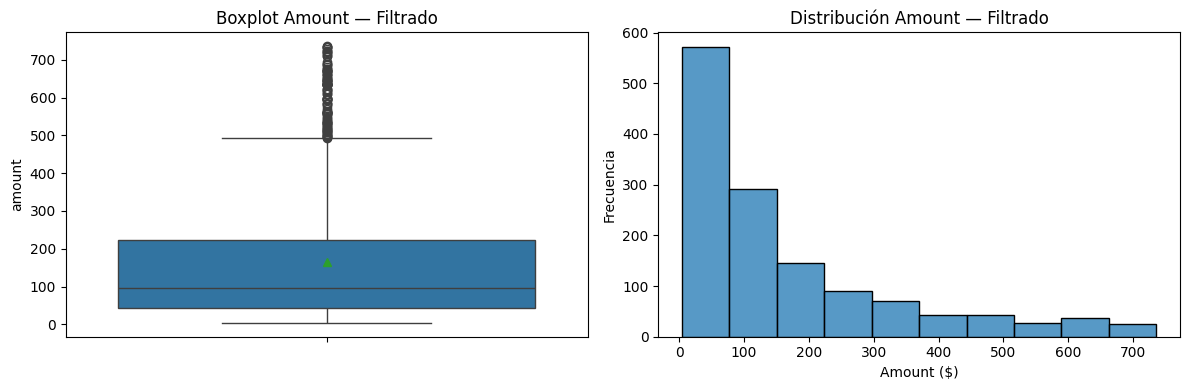

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(df_od_filtrado['amount'], ax=ax[0], showmeans=True)
ax[0].set_title('Boxplot Amount — Filtrado')
sns.histplot(df_od_filtrado['amount'], bins=10, ax=ax[1])
ax[1].set_title('Distribución Amount — Filtrado')
ax[1].set_xlabel('Amount ($)')
ax[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# HALLAZGO: distribución sesgada a la derecha — mayoría de ventas en montos bajos con cola hacia valores altos

## 6. Análisis de Ventas

### 6.1 Correlaciones

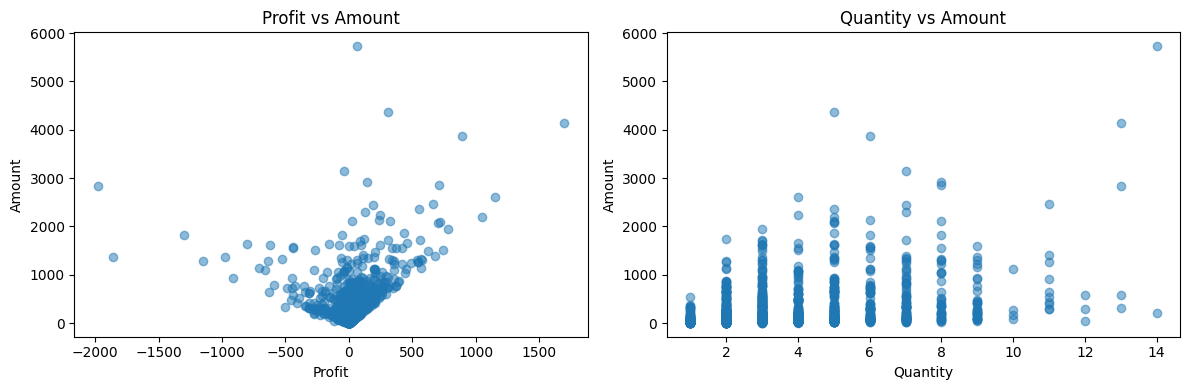

Correlación Profit  / Amount   : 0.24 — positiva débil
Correlación Quantity / Amount  : 0.35 — positiva débil

HALLAZGO: ni el profit ni la cantidad son factores determinantes del monto de venta.
Clientes compran muchos productos baratos o pocos productos caros indistintamente.


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(df_orders_details['profit'], df_orders_details['amount'], alpha=0.5)
ax[0].set_title('Profit vs Amount')
ax[0].set_xlabel('Profit')
ax[0].set_ylabel('Amount')
ax[1].scatter(df_orders_details['quantity'], df_orders_details['amount'], alpha=0.5)
ax[1].set_title('Quantity vs Amount')
ax[1].set_xlabel('Quantity')
ax[1].set_ylabel('Amount')
plt.tight_layout()
plt.show()

corr_pa = df_orders_details['profit'].corr(df_orders_details['amount'])
corr_qa = df_orders_details['quantity'].corr(df_orders_details['amount'])

print(f'Correlación Profit  / Amount   : {corr_pa:.2f} — positiva débil')
print(f'Correlación Quantity / Amount  : {corr_qa:.2f} — positiva débil')
print()
print('HALLAZGO: ni el profit ni la cantidad son factores determinantes del monto de venta.')
print('Clientes compran muchos productos baratos o pocos productos caros indistintamente.')

### 6.2 Tendencia de Ventas Mensual — 2018 vs 2019

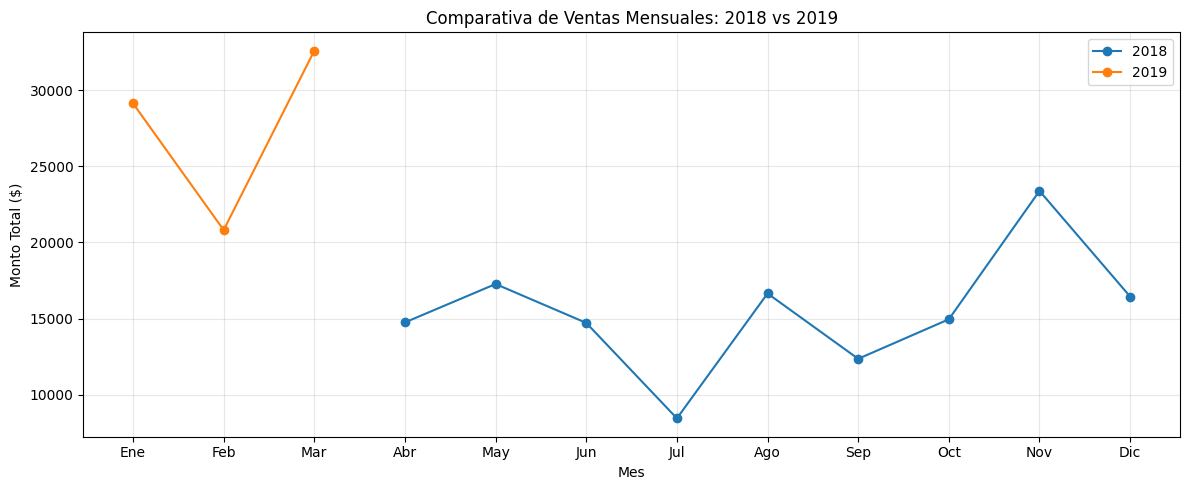

2018 — Mes con más ventas: Mes 11 | $23,389
2019 — Mes con más ventas: Mes 3 | $32,601

HALLAZGO: 2019 supera a 2018 en su pico máximo (~44% más). No hay estacionalidad clara.


In [20]:
df_temporal = df_od_filtrado.merge(df_orders_list[['order_id', 'order_date']], on='order_id')
df_temporal['year'] = df_temporal['order_date'].dt.year

df_2018 = df_temporal[df_temporal['year'] == 2018]
df_2019 = df_temporal[df_temporal['year'] == 2019]

ventas_2018 = df_2018.set_index('order_date')['amount'].resample('ME').sum()
ventas_2019 = df_2019.set_index('order_date')['amount'].resample('ME').sum()

plt.figure(figsize=(12, 5))
plt.plot(ventas_2018.index.month, ventas_2018.values, label='2018', marker='o')
plt.plot(ventas_2019.index.month, ventas_2019.values, label='2019', marker='o')
plt.title('Comparativa de Ventas Mensuales: 2018 vs 2019')
plt.xlabel('Mes')
plt.ylabel('Monto Total ($)')
plt.xticks(range(1, 13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mes_max_2018 = ventas_2018.idxmax().month
val_max_2018 = ventas_2018.max()
mes_max_2019 = ventas_2019.idxmax().month
val_max_2019 = ventas_2019.max()

print(f'2018 — Mes con más ventas: Mes {mes_max_2018} | ${val_max_2018:,.0f}')
print(f'2019 — Mes con más ventas: Mes {mes_max_2019} | ${val_max_2019:,.0f}')
print()
print('HALLAZGO: 2019 supera a 2018 en su pico máximo (~44% más). No hay estacionalidad clara.')

## 7. Análisis de Productos

### 7.1 ¿Qué categoría genera más ganancias?

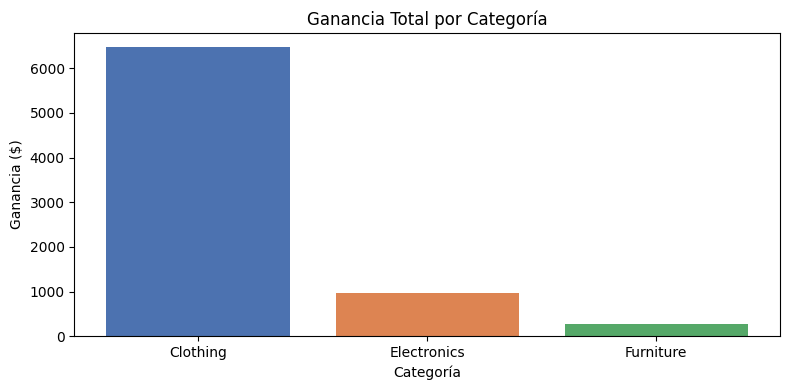

Clothing        | $   6,468 | 84.1%
Electronics     | $     960 | 12.5%
Furniture       | $     263 | 3.4%

HALLAZGO: Clothing representa el 84% de la ganancia total de la empresa.


In [21]:
categorias   = df_od_filtrado.groupby('category')['profit'].sum().sort_values(ascending=False)
total_profit = categorias.sum()

plt.figure(figsize=(8, 4))
plt.bar(categorias.index, categorias.values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Ganancia Total por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ganancia ($)')
plt.tight_layout()
plt.show()

for cat, val in categorias.items():
    pct = val / total_profit * 100
    print(f'{cat:<15} | ${val:>8,.0f} | {pct:.1f}%')

print()
print('HALLAZGO: Clothing representa el 84% de la ganancia total de la empresa.')

### 7.2 ¿Qué sub-categoría es la más rentable?

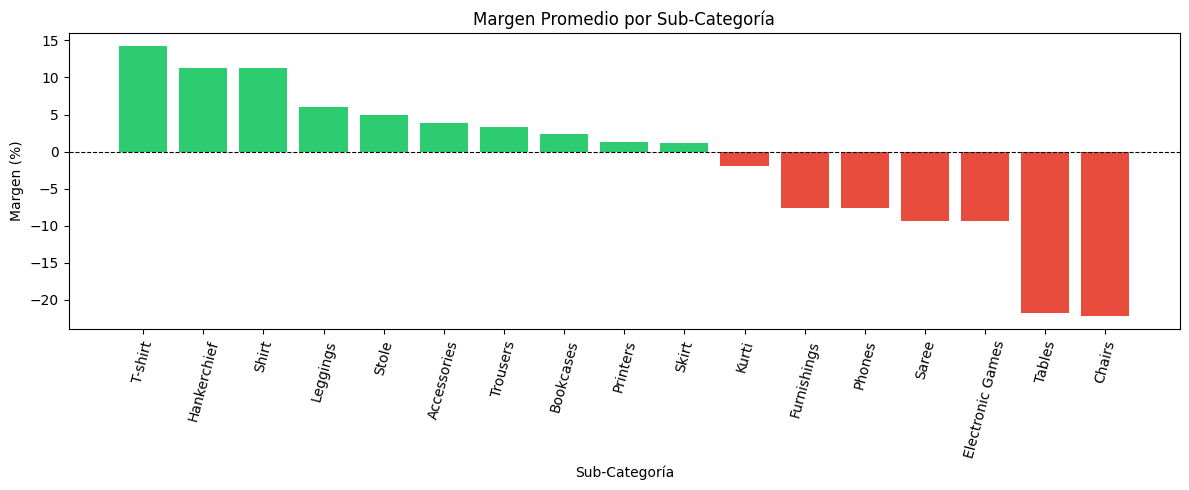

HALLAZGO: T-Shirt lidera el margen. Chairs, Tables y Saree tienen margen negativo.


In [22]:
df_od_filtrado['margin'] = df_od_filtrado['profit'] / df_od_filtrado['amount'] * 100
sub_cat_margen = df_od_filtrado.groupby('sub_category')['margin'].mean().sort_values(ascending=False)

colores = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sub_cat_margen.values]
plt.figure(figsize=(12, 5))
plt.bar(sub_cat_margen.index, sub_cat_margen.values, color=colores)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Margen Promedio por Sub-Categoría')
plt.xlabel('Sub-Categoría')
plt.ylabel('Margen (%)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

print('HALLAZGO: T-Shirt lidera el margen. Chairs, Tables y Saree tienen margen negativo.')

### 7.3 ¿Hay sub-categorías con alto volumen pero profit negativo?

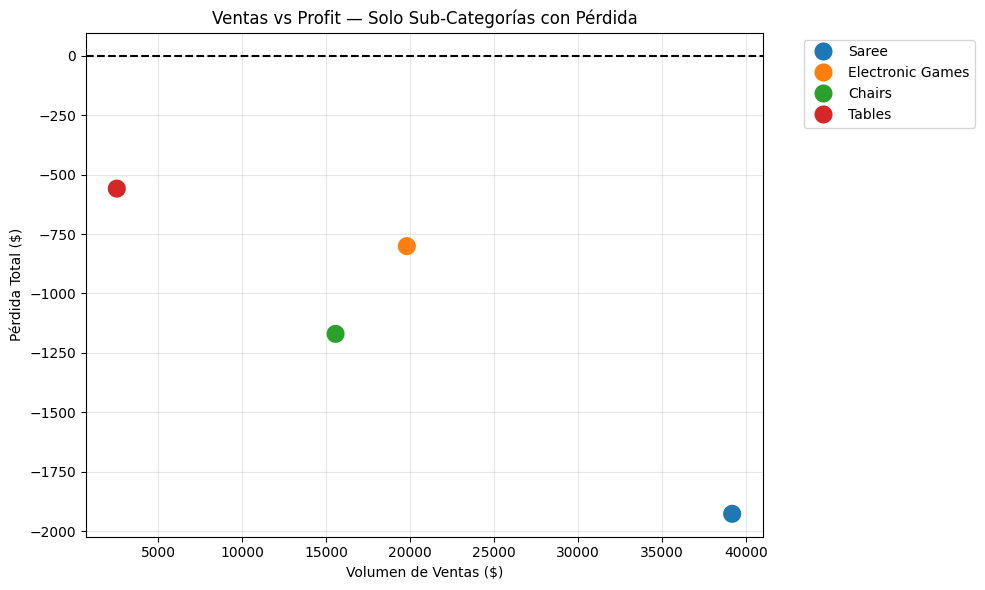

HALLAZGO: Saree vende mucho pero pierde ~$1,190. Electronics y Chairs en zona de riesgo media.


In [23]:
p_negativo = dk.sql("""
    SELECT sub_category,
           SUM(profit) AS total_profit,
           SUM(amount) AS total_sales
    FROM df_od_filtrado
    GROUP BY sub_category
    HAVING total_profit < 0
    ORDER BY total_sales DESC
""").df()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=p_negativo, x='total_sales', y='total_profit', hue='sub_category', s=200)
plt.axhline(0, color='black', linestyle='--')
plt.title('Ventas vs Profit — Solo Sub-Categorías con Pérdida')
plt.xlabel('Volumen de Ventas ($)')
plt.ylabel('Pérdida Total ($)')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('HALLAZGO: Saree vende mucho pero pierde ~$1,190. Electronics y Chairs en zona de riesgo media.')

## 8. Análisis de Clientes

### 8.1 Top 10 Clientes por Ingreso

C:\Users\aace\AppData\Local\Temp\ipykernel_10148\3130093158.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_clientes, x='cliente', y='total_ventas', palette='Blues_d')


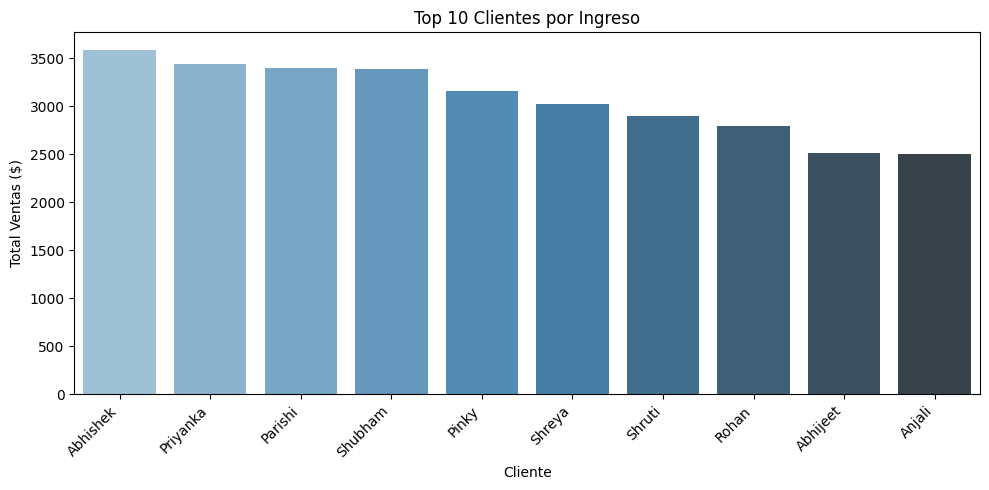

,cliente,total_ventas
0,Abhishek,3593.0
1,Priyanka,3438.0
2,Parishi,3404.0
3,Shubham,3387.0
4,Pinky,3160.0
5,Shreya,3023.0
6,Shruti,2900.0
7,Rohan,2798.0
8,Abhijeet,2516.0
9,Anjali,2507.0



RECOMENDACIÓN: Aplicar descuentos estratégicos en sub-categorías con margen negativo
dirigidos a estos clientes para analizar evolución de rentabilidad.


In [24]:
top10_clientes = dk.sql("""
    SELECT c.customer_name AS cliente,
           SUM(od.amount)  AS total_ventas
    FROM df_orders_list AS c
    INNER JOIN df_od_filtrado AS od ON c.order_id = od.order_id
    GROUP BY c.customer_name
    ORDER BY total_ventas DESC
    LIMIT 10
""").df()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_clientes, x='cliente', y='total_ventas', palette='Blues_d')
plt.title('Top 10 Clientes por Ingreso')
plt.xlabel('Cliente')
plt.ylabel('Total Ventas ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(top10_clientes)

print()
print('RECOMENDACIÓN: Aplicar descuentos estratégicos en sub-categorías con margen negativo')
print('dirigidos a estos clientes para analizar evolución de rentabilidad.')

## 9. Análisis Geográfico
> Analizamos el comportamiento de ventas y rentabilidad por estado y ciudad.

### 9.1 ¿Qué estados generan más ventas y cuáles tienen profit negativo?

C:\Users\aace\AppData\Local\Temp\ipykernel_10148\2875601638.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=estados_ventas, x='State', y='Total', ax=ax[0], palette='Blues_d')
C:\Users\aace\AppData\Local\Temp\ipykernel_10148\2875601638.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\aace\AppData\Local\Temp\ipykernel_10148\2875601638.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=estados_p_negativo, x='Profit', y='State', ax=ax[1], palette='Reds_r')


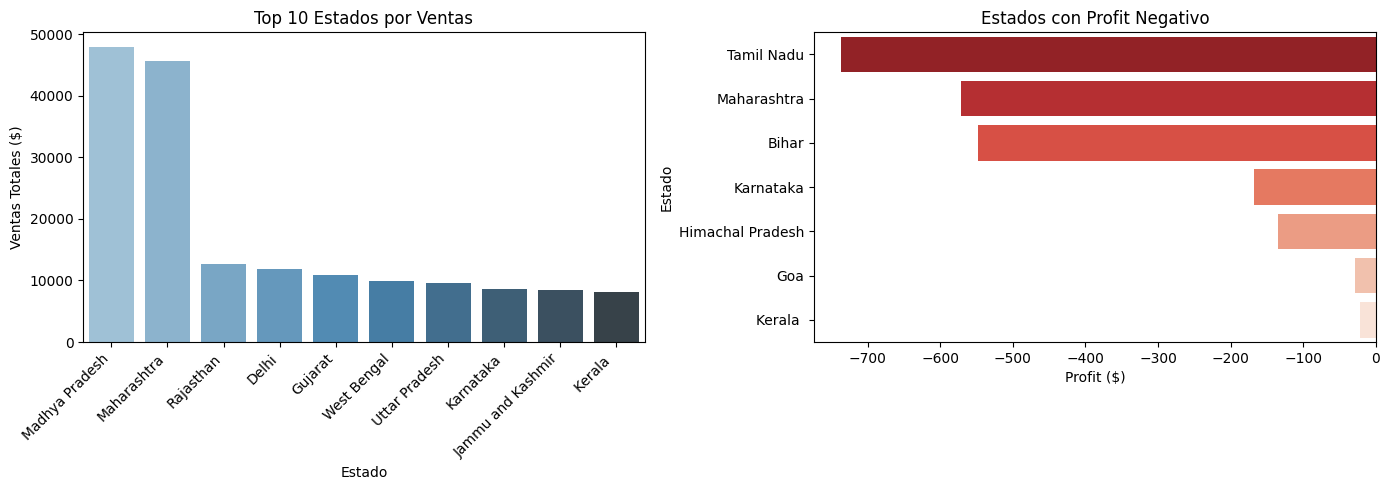

HALLAZGO: Madhya Pradesh lidera en ventas con amplia diferencia.
Tamil Nadu es el estado con mayores pérdidas — evaluar estrategia comercial en esa región.


In [25]:
estados_ventas = dk.sql("""
    SELECT l.state AS State, SUM(f.amount) AS Total
    FROM df_orders_list AS l
    INNER JOIN df_od_filtrado AS f ON l.order_id = f.order_id
    GROUP BY State
    HAVING Total > 0
    ORDER BY Total DESC
    LIMIT 10
""").df()

estados_p_negativo = dk.sql("""
    SELECT l.state AS State, SUM(f.profit) AS Profit
    FROM df_orders_list AS l
    INNER JOIN df_od_filtrado AS f ON l.order_id = f.order_id
    GROUP BY State
    HAVING Profit < 0
    ORDER BY Profit ASC
""").df()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=estados_ventas, x='State', y='Total', ax=ax[0], palette='Blues_d')
ax[0].set_title('Top 10 Estados por Ventas')
ax[0].set_xlabel('Estado')
ax[0].set_ylabel('Ventas Totales ($)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(data=estados_p_negativo, x='Profit', y='State', ax=ax[1], palette='Reds_r')
ax[1].set_title('Estados con Profit Negativo')
ax[1].set_xlabel('Profit ($)')
ax[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

print('HALLAZGO: Madhya Pradesh lidera en ventas con amplia diferencia.')
print('Tamil Nadu es el estado con mayores pérdidas — evaluar estrategia comercial en esa región.')

### 9.2 ¿Hay estados con alto volumen de ventas pero bajo profit?

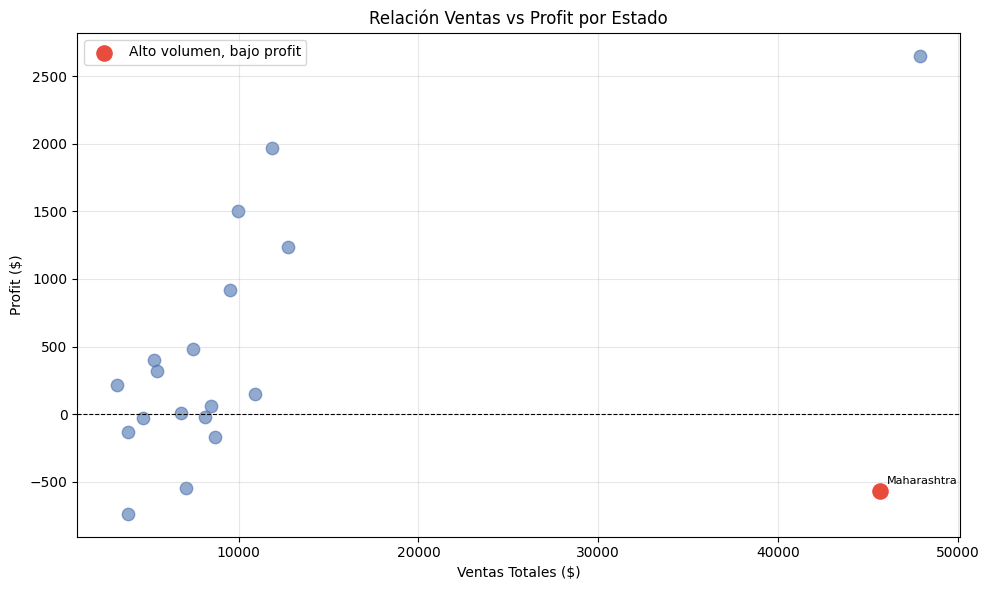

HALLAZGO: Algunos estados venden mucho pero generan poco o negativo profit.
Candidatos prioritarios para auditar costos y estrategia de precios.



,State,Sales,Profit
0,Maharashtra,45684.0,-571.0


In [26]:
estados = dk.sql("""
    SELECT
        l.state AS State,
        SUM(f.amount) AS Sales,
        SUM(f.profit) AS Profit
    FROM df_orders_list AS l
    INNER JOIN df_od_filtrado AS f ON l.order_id = f.order_id
    GROUP BY State
""").df()

high_sales = estados['Sales'].quantile(0.75)
low_profit = estados['Profit'].quantile(0.25)
casos      = estados[(estados['Sales'] >= high_sales) & (estados['Profit'] <= low_profit)]

plt.figure(figsize=(10, 6))
plt.scatter(estados['Sales'], estados['Profit'], alpha=0.6, color='#4C72B0', s=80)
plt.scatter(casos['Sales'], casos['Profit'], color='#e74c3c', s=120,
            label='Alto volumen, bajo profit', zorder=5)

for _, row in casos.iterrows():
    plt.annotate(row['State'], (row['Sales'], row['Profit']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Relación Ventas vs Profit por Estado')
plt.xlabel('Ventas Totales ($)')
plt.ylabel('Profit ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('HALLAZGO: Algunos estados venden mucho pero generan poco o negativo profit.')
print('Candidatos prioritarios para auditar costos y estrategia de precios.')
print()
display(casos[['State', 'Sales', 'Profit']].reset_index(drop=True))

### 9.3 ¿Qué ciudades concentran más órdenes?

C:\Users\aace\AppData\Local\Temp\ipykernel_10148\3470832768.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ciudades, x='City', y='Total_ordenes', palette='Blues_d')


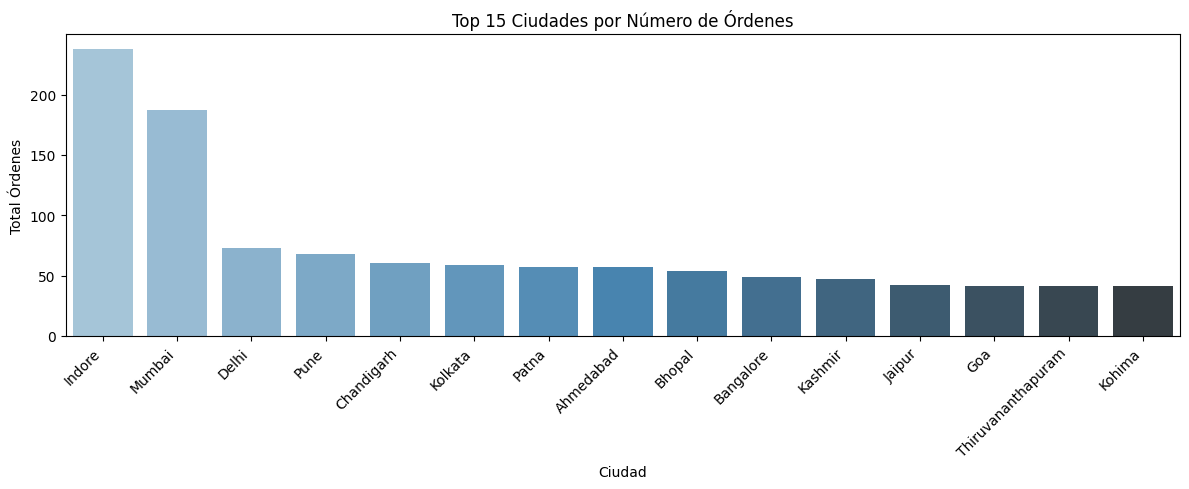

HALLAZGO: La concentración de órdenes en pocas ciudades indica dónde enfocar
operaciones logísticas y campañas de marketing local.


In [27]:
ciudades = dk.sql("""
    SELECT l.city AS City, COUNT(f.order_id) AS Total_ordenes
    FROM df_od_filtrado AS f
    INNER JOIN df_orders_list AS l ON f.order_id = l.order_id
    GROUP BY City
    ORDER BY Total_ordenes DESC
    LIMIT 15
""").df()

plt.figure(figsize=(12, 5))
sns.barplot(data=ciudades, x='City', y='Total_ordenes', palette='Blues_d')
plt.title('Top 15 Ciudades por Número de Órdenes')
plt.xlabel('Ciudad')
plt.ylabel('Total Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('HALLAZGO: La concentración de órdenes en pocas ciudades indica dónde enfocar')
print('operaciones logísticas y campañas de marketing local.')

## 10. Conclusiones

| # | Hallazgo | Impacto |
|---|---|---|
| 1 | **Clothing genera el 84% del profit total** | Categoría clave — priorizar inventario y marketing |
| 2 | **Saree: alto volumen, profit negativo (-$1,190)** | Revisar estructura de costos o precio de venta |
| 3 | **Electronics y Chairs en zona de pérdida media** | Candidatos a rediseño de estrategia comercial |
| 4 | **T-Shirt tiene el mejor margen** | Potenciar ventas cruzadas con esta sub-categoría |
| 5 | **2019 supera a 2018 en pico de ventas (~44%)** | Tendencia de crecimiento positiva |
| 6 | **Correlación ventas-cantidad es débil (0.18)** | El precio unitario importa más que el volumen |
| 7 | **Tamil Nadu: mayor pérdida geográfica** | Auditar operaciones y precios en esa región |
| 8 | **Madhya Pradesh lidera en ventas** | Reforzar logística y disponibilidad en ese estado |

